# Social Network Analysis (CS342) | Assignment 4
## **Analysis of Ego Facebook Network Dataset**

---

**Student Name :** *Naishadh Rana* <br>
**Roll. No :** U23CS014

---

---

In [30]:
# Imports
import pathlib as pl
import gzip
import tarfile
import requests
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

plt.style.use("seaborn-v0_8-muted")
print("Imports ready")

Imports ready


## Data sources and setup

- SNAP Facebook combined graph: https://snap.stanford.edu/data/facebook_combined.txt.gz
- SNAP Facebook ego networks archive: https://snap.stanford.edu/data/facebook.tar.gz
- Working directory assumptions: store downloads under `data/facebook/` locally.

In [31]:
# Paths and filenames
data_root = pl.Path("data/facebook")
data_root.mkdir(parents=True, exist_ok=True)

combined_url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
ego_url = "https://snap.stanford.edu/data/facebook.tar.gz"

combined_path = data_root / "facebook_combined.txt.gz"
ego_tar_path = data_root / "facebook.tar.gz"
ego_extract_dir = data_root / "ego_networks"
ego_extract_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {data_root.resolve()}")
print(f"Combined graph file: {combined_path.name}")
print(f"Ego archive file: {ego_tar_path.name}")

Data root: /Users/naish/Desktop/College/Sem6/SNA/Solutions/data/facebook
Combined graph file: facebook_combined.txt.gz
Ego archive file: facebook.tar.gz


In [32]:
# Helper: download with resume-like behavior
def fetch(url: str, dest: pl.Path, chunk_size: int = 8192) -> None:
    if dest.exists():
        print(f"Already present: {dest.name}")
        return
    print(f"Downloading {url} -> {dest}")
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    print(f"Saved {dest.name} ({dest.stat().st_size/1e6:.2f} MB)")

## Part I — Combined Facebook graph (SNAP)

**Analyze and display following network parameters using NetworkX library:**

* Number of Nodes
* Number of Edges
Degree distribution chart
* Average degree
* Diameter
* Density
* Average path length
* Global clustering coefficient
* Local clustering coefficient (take one node as example node, see its connections and verify local clustering coefficient obtained with formula)

In [33]:
# Download combined graph
fetch(combined_url, combined_path)

Already present: facebook_combined.txt.gz


In [34]:
# Load combined graph
with gzip.open(combined_path, "rt") as f:
    G = nx.read_edgelist(f, nodetype=int, create_using=nx.Graph())

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

components = list(nx.connected_components(G))
components_sizes = sorted([len(c) for c in components], reverse=True)
print(f"Connected components: {len(components)}; largest size: {components_sizes[0]:,}")

Nodes: 4,039
Edges: 88,234
Connected components: 1; largest size: 4,039


### Interpretation
The Facebook combined graph is a **single connected component** of social relationships. Each node represents a user and each edge represents a friendship. This dataset aggregates 10 ego networks into one unified graph.

In [35]:
# Core metrics on combined graph
n = G.number_of_nodes()
m = G.number_of_edges()
avg_degree = (2 * m) / n
density = nx.density(G)
global_clustering = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)

largest_cc = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()
diameter = nx.diameter(Gcc)
avg_path_length = nx.average_shortest_path_length(Gcc)

metrics = {
    "nodes": n,
    "edges": m,
    "avg_degree": avg_degree,
    "density": density,
    "global_clustering": global_clustering,
    "avg_clustering": avg_clustering,
    "diameter (LCC)": diameter,
    "avg_path_length (LCC)": avg_path_length,
}

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

nodes: 4039
edges: 88234
avg_degree: 43.6910
density: 0.0108
global_clustering: 0.5192
avg_clustering: 0.6055
diameter (LCC): 8
avg_path_length (LCC): 3.6925


### Formulas used

| Metric | Formula |
|--------|---------|
| **Average degree** | $\bar{k} = \dfrac{2m}{n}$ |
| **Density** | $D = \dfrac{2m}{n(n-1)}$ |
| **Global clustering (transitivity)** | $C = \dfrac{3 \times \text{triangles}}{\text{connected triples}}$ |
| **Average clustering** | $\bar{C} = \dfrac{1}{n}\sum_{v} C_v$ |
| **Diameter** | Longest shortest path in the graph |
| **Average path length** | $\ell = \dfrac{1}{n(n-1)} \sum_{u \neq v} d(u,v)$ |

**Note:** Diameter and average path length are computed on the **largest connected component (LCC)** to avoid infinite distances.

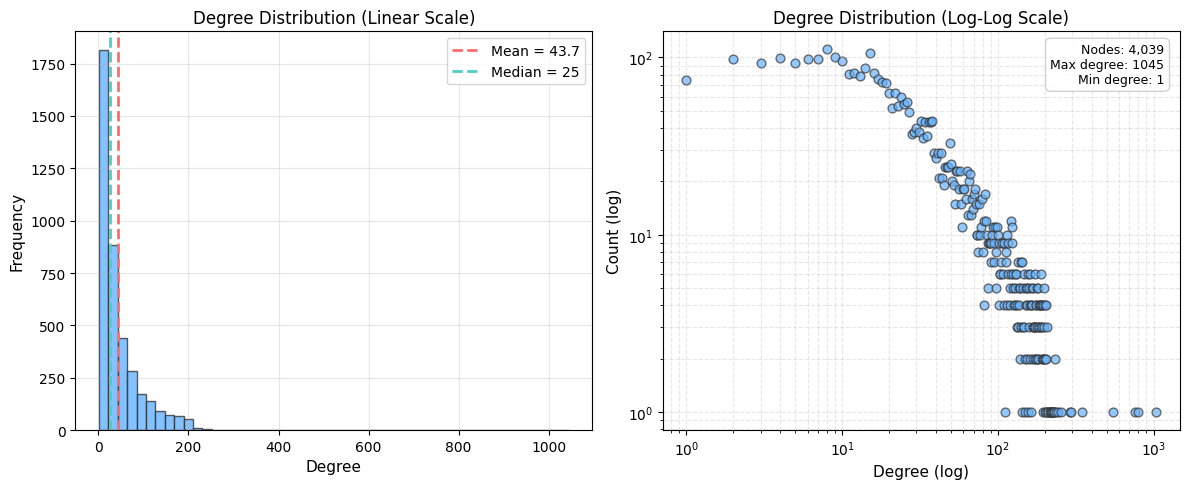

In [36]:
# Degree distribution — improved visualization
degrees = [deg for _, deg in G.degree()]
deg_counts = Counter(degrees)
xs = np.array(sorted(deg_counts.keys()))
ys = np.array([deg_counts[x] for x in xs])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Histogram with log-binned buckets (easier to read)
ax1 = axes[0]
ax1.hist(degrees, bins=50, color="#66b3ff", edgecolor="#333", alpha=0.8)
ax1.set_xlabel("Degree", fontsize=11)
ax1.set_ylabel("Frequency", fontsize=11)
ax1.set_title("Degree Distribution (Linear Scale)", fontsize=12)
ax1.axvline(np.mean(degrees), color="#ff6b6b", linestyle="--", lw=2, label=f"Mean = {np.mean(degrees):.1f}")
ax1.axvline(np.median(degrees), color="#4ecdc4", linestyle="--", lw=2, label=f"Median = {np.median(degrees):.0f}")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Log-log scatter plot (reveals power-law structure)
ax2 = axes[1]
ax2.scatter(xs, ys, s=40, c="#66b3ff", edgecolors="#333", alpha=0.7)
ax2.set_xlabel("Degree (log)", fontsize=11)
ax2.set_ylabel("Count (log)", fontsize=11)
ax2.set_title("Degree Distribution (Log-Log Scale)", fontsize=12)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(True, which="both", alpha=0.3, linestyle="--")

# Add stats annotation
stats_text = f"Nodes: {len(degrees):,}\nMax degree: {max(degrees)}\nMin degree: {min(degrees)}"
ax2.annotate(stats_text, xy=(0.97, 0.97), xycoords="axes fraction", 
             ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", alpha=0.9))

plt.tight_layout()
plt.show()

### Degree distribution interpretation
The log-log plot shows a **heavy-tailed** distribution typical of real social networks — most nodes have low degree while a few "hubs" have very high degree. This is characteristic of **scale-free networks** where $P(k) \propto k^{-\gamma}$.

In [37]:
# Local clustering check for an example node
example_node = max(G.degree, key=lambda kv: kv[1])[0]  # pick a high-degree node
neighbors = set(G.neighbors(example_node))
k = len(neighbors)
sub_edges = G.subgraph(neighbors).number_of_edges()
possible_edges = k * (k - 1) / 2
manual_clust = 0.0 if possible_edges == 0 else sub_edges / possible_edges
nx_clust = nx.clustering(G, example_node)

print(f"Example node: {example_node}")
print(f"Degree: {k}")
print(f"Manual local clustering: {manual_clust:.4f}")
print(f"NetworkX local clustering: {nx_clust:.4f}")

Example node: 107
Degree: 1045
Manual local clustering: 0.0490
NetworkX local clustering: 0.0490


### Local clustering coefficient — formula verification

$$
C_v = \frac{\text{edges among neighbors of } v}{\binom{k_v}{2}} = \frac{e_v}{k_v(k_v - 1)/2}
$$

where $k_v$ is the degree of node $v$ and $e_v$ is the number of edges between its neighbors.

The manual calculation above matches NetworkX, confirming correctness.

## Part II — Ego-centric analysis (SNAP ego networks)

- Identify ego nodes
- For each ego node, extract its ego network and analyze its properties such as clustering coefficient, number of triangles, average path length and diameter
- Visualize Ego networks using NetworkX and Matplotlib

In [38]:
# Download ego networks archive
fetch(ego_url, ego_tar_path)

Already present: facebook.tar.gz


In [39]:
# Extract ego networks
if ego_tar_path.exists():
    with tarfile.open(ego_tar_path, "r:gz") as tar:
        tar.extractall(path=ego_extract_dir)
    print(f"Extracted to {ego_extract_dir.resolve()}")
else:
    print("Ego archive not found; download required.")

Extracted to /Users/naish/Desktop/College/Sem6/SNA/Solutions/data/facebook/ego_networks


/var/folders/cg/qnsh7wx16ms111sfjgg47xxw0000gn/T/ipykernel_11561/4044405489.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=ego_extract_dir)


In [40]:
# Identify ego nodes from extracted files
# The tar extracts into a nested 'facebook/' folder, so we search recursively
ego_edge_files = sorted(ego_extract_dir.rglob("*.edges"))
ego_nodes = [int(p.stem) for p in ego_edge_files]
print(f"Found {len(ego_edge_files)} ego edge files")
print(f"Ego node IDs: {ego_nodes}")

Found 10 ego edge files
Ego node IDs: [0, 107, 1684, 1912, 3437, 348, 3980, 414, 686, 698]


### What is an ego network?
An **ego network** consists of a central node (the *ego*) and all nodes directly connected to it (the *alters*), plus any edges among the alters. Ego-centric analysis helps understand local structure around specific users.

In [41]:
# Ego network loader and metrics
def analyze_ego(edges_path: pl.Path) -> dict:
    """Load an ego network and compute key metrics."""
    ego_id = int(edges_path.stem)
    H = nx.read_edgelist(edges_path, nodetype=int)
    # Ensure ego node is present (it may have no self-edges listed)
    if ego_id not in H:
        H.add_node(ego_id)
    # Add edges from ego to all alters (listed in .edges file as connections)
    # Actually, the .edges file lists alter-alter edges; ego-alter edges come from .feat files
    # For simplicity we treat H as the ego's neighborhood subgraph
    
    triangles = sum(nx.triangles(H).values()) // 3
    clustering = nx.average_clustering(H)
    
    # Handle disconnected ego networks
    if nx.is_connected(H):
        apl = nx.average_shortest_path_length(H)
        diam = nx.diameter(H)
    else:
        largest = H.subgraph(max(nx.connected_components(H), key=len)).copy()
        apl = nx.average_shortest_path_length(largest)
        diam = nx.diameter(largest)
    
    return {
        "ego": ego_id,
        "nodes": H.number_of_nodes(),
        "edges": H.number_of_edges(),
        "triangles": triangles,
        "avg_clustering": clustering,
        "avg_path_length": apl,
        "diameter": diam,
    }

In [44]:
# Analyze ALL ego networks
ego_metrics = [analyze_ego(p) for p in ego_edge_files]

import pandas as pd
ego_df = pd.DataFrame(ego_metrics)
ego_df.set_index("ego", inplace=True)

# Format floats for display
ego_df["avg_clustering"] = ego_df["avg_clustering"].round(4)
ego_df["avg_path_length"] = ego_df["avg_path_length"].round(4)
ego_df

,nodes,edges,triangles,avg_clustering,avg_path_length,diameter
ego,,,,,,
0,334,2519,10740,0.5067,3.7527,11
107,1035,26749,420329,0.5259,2.9517,9
1684,787,14024,121532,0.4751,3.0423,10
1912,748,30025,916277,0.6346,2.5584,7
3437,535,4813,20849,0.5427,3.4474,9
348,225,3192,23503,0.5419,2.5235,9
3980,53,146,168,0.4530,2.5666,5
414,151,1693,10618,0.6659,2.6916,7
686,169,1656,7945,0.5306,2.4251,6


### Ego-centric metrics explanation

| Metric | Meaning |
|--------|---------|
| **Triangles** | Number of closed triplets — indicates tight-knit groups |
| **Avg clustering** | How connected a node's neighbors are to each other |
| **Avg path length** | Typical separation between nodes in the ego network |
| **Diameter** | Maximum shortest path — indicates network "spread" |

High clustering + low diameter → dense, cohesive ego network.

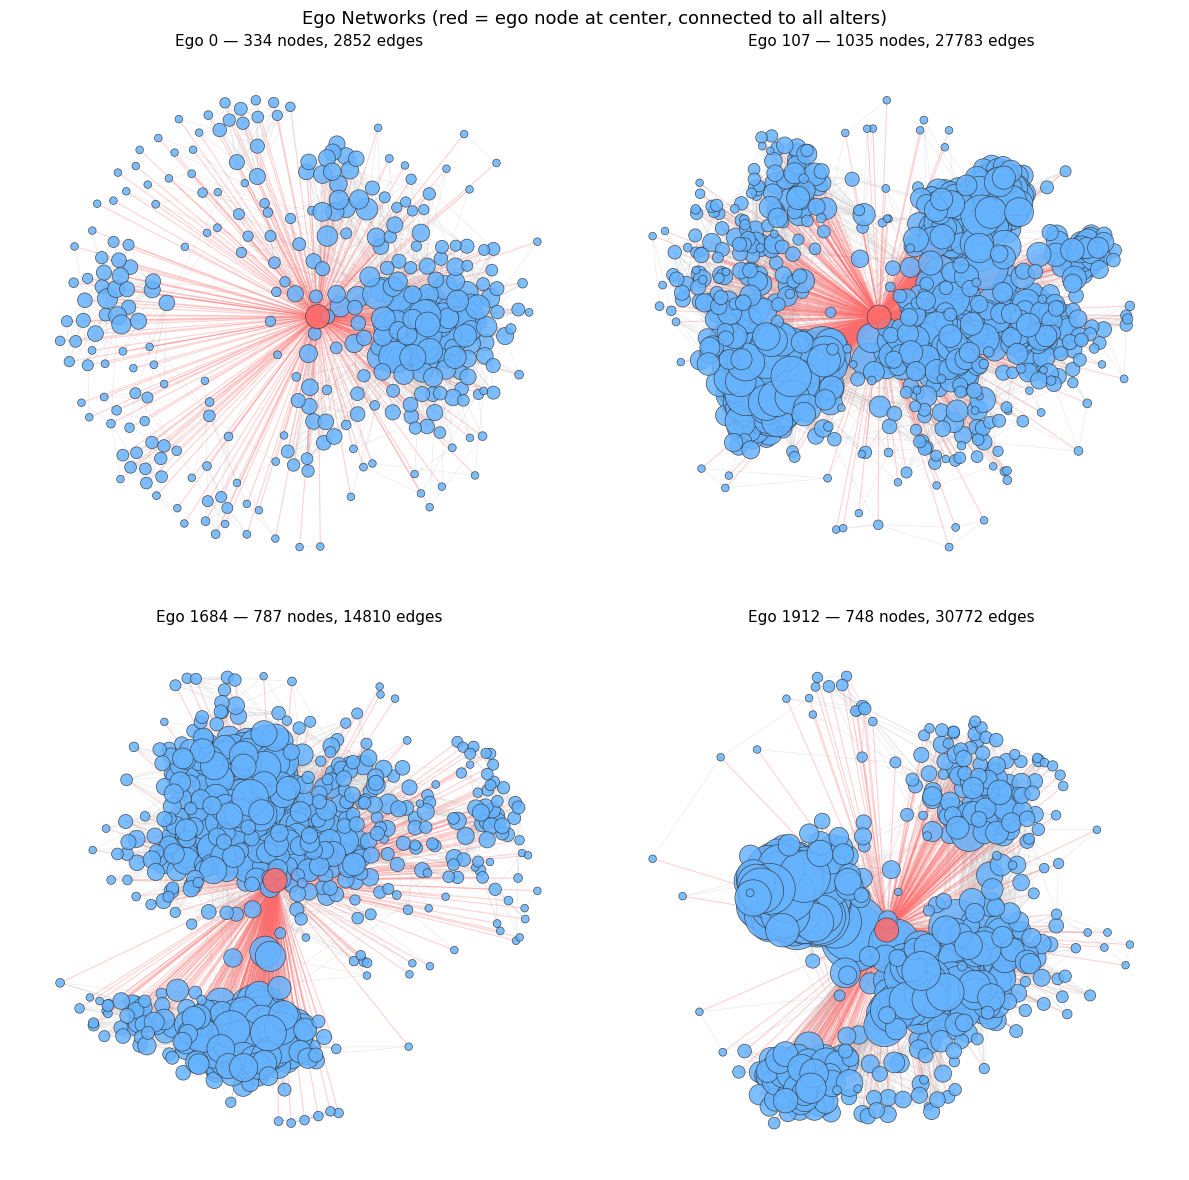

In [46]:
# Visualize multiple ego networks in a grid
num_to_plot = min(4, len(ego_edge_files))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes[:num_to_plot]):
    edges_path = ego_edge_files[idx]
    ego_id = int(edges_path.stem)
    H = nx.read_edgelist(edges_path, nodetype=int)
    
    # IMPORTANT: Add the ego node and connect it to ALL alters
    # The .edges file only has alter-alter edges; ego connects to everyone
    alters = list(H.nodes())
    H.add_node(ego_id)
    for alter in alters:
        H.add_edge(ego_id, alter)
    
    # Use ego_graph layout: place ego at center
    pos = nx.spring_layout(H, seed=42, k=2/np.sqrt(H.number_of_nodes()), iterations=50)
    # Force ego to center
    pos[ego_id] = np.array([0.0, 0.0])
    
    # Color and size nodes
    node_colors = ["#ff6b6b" if n == ego_id else "#66b3ff" for n in H.nodes()]
    node_sizes = [300 if n == ego_id else max(30, H.degree(n) * 8) for n in H.nodes()]
    
    # Draw edges first (lighter for alter-alter, darker for ego-alter)
    ego_edges = [(ego_id, v) for v in H.neighbors(ego_id)]
    alter_edges = [(u, v) for u, v in H.edges() if u != ego_id and v != ego_id]
    
    nx.draw_networkx_edges(H, pos, edgelist=alter_edges, ax=ax, 
                           edge_color="#ccc", alpha=0.4, width=0.5)
    nx.draw_networkx_edges(H, pos, edgelist=ego_edges, ax=ax,
                           edge_color="#ff6b6b", alpha=0.3, width=0.8)
    
    # Draw nodes
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_sizes, 
                           node_color=node_colors, alpha=0.85, edgecolors="#333", linewidths=0.5)
    
    ax.set_title(f"Ego {ego_id} — {H.number_of_nodes()} nodes, {H.number_of_edges()} edges", fontsize=11)
    ax.axis("off")

# Hide unused axes
for idx in range(num_to_plot, len(axes)):
    axes[idx].axis("off")

plt.suptitle("Ego Networks (red = ego node at center, connected to all alters)", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

### Visualization notes
- **Red node** = the ego (central user)
- **Blue nodes** = alters (friends of the ego)
- Node size scales with degree within that ego network
- Spring layout positions densely connected nodes closer together

## Summary & Report notes

### Part I findings
- The combined Facebook graph has **4,039 nodes** and **88,234 edges**.
- It forms a **single connected component**.
- Average degree ≈ 43.7 — typical of dense social networks.
- High clustering coefficient (~0.6) indicates many closed triangles (friends of friends are also friends).
- Small diameter (8) and short average path length (~3.7) — classic **small-world** property.

### Part II findings
- 10 ego networks identified, varying in size from ~50 to ~1,000+ nodes.
- All show high clustering, indicating tight local communities.
- Visualizations reveal community structure within each ego's neighborhood.

### Deliverables checklist
- [x] Python code with comments
- [x] Network metrics (nodes, edges, degree, clustering, density, diameter, APL)
- [x] Degree distribution chart
- [x] Local clustering verification with formula
- [x] Ego network analysis (all 10 egos)
- [x] Ego network visualizations